In [47]:
import torch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.manifold_laplacian_net import ManifoldLaplacianNet

In [48]:
def save_combined_plots(non_uniform_x, f, uniform_x, f_uniform):
    """
    Creates one combined figure with two columns:
    Left Column (Non-Uniform):
        - The top self.hparams.k subplots: each eigenvector (with ylims [-0.15, 0.15])
        plotted versus non_uniform_x (line + scatter markers).
        - The bottom subplot: a heatmap of the dot-product matrix for non-uniform eigenvectors.
    Right Column (Uniform):
        - The top self.hparams.k subplots: each eigenvector (with ylims [-0.15, 0.15])
        plotted versus uniform_x (line + scatter markers).
        - The bottom subplot: a heatmap of the dot-product matrix for uniform eigenvectors.
    Additionally, titles are added above each column.
    """
    sns.set_style('whitegrid')

    num_eigen = 5           # Number of eigenvectors (and eigenvector subplots per block)
    num_rows = num_eigen + 1             # k rows for eigenvector plots + 1 row for the heatmap
    num_cols = 2                       # Left column: non-uniform, Right column: uniform

    # Determine x-axis limits for each case.
    x_min_non, x_max_non = np.min(non_uniform_x), np.max(non_uniform_x)
    x_min_uniform, x_max_uniform = np.min(uniform_x), np.max(uniform_x)

    # Set height ratios: give each eigenvector row a ratio of 1 and the heatmap a larger ratio (e.g., 3).
    height_ratios = [1] * num_eigen + [3]

    # Adjust overall figure size.
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols,
                            figsize=(18, (num_rows + 2) * 2),
                            gridspec_kw={'height_ratios': height_ratios})

    # --- Plot Eigenvectors ---
    for i in range(num_eigen):
        # Left Column: Non-uniform eigenvectors.
        ax_non = axes[i, 0]
        ax_non.plot(non_uniform_x, f[i], color=f'C{i}', label=f'Eigenvector {i+1}')
        ax_non.scatter(non_uniform_x, f[i], color='blue', s=10)
        ax_non.set_xlim(x_min_non, x_max_non)
        ax_non.set_ylim(-0.15, 0.15)
        ax_non.set_ylabel('Value', fontsize=10)
        ax_non.legend(fontsize=8)

        # Right Column: Uniform eigenvectors.
        ax_uniform = axes[i, 1]
        ax_uniform.plot(uniform_x, f_uniform[i], color=f'C{i}', label=f'Eigenvector {i+1}')
        ax_uniform.scatter(uniform_x, f_uniform[i], color='blue', s=10)
        ax_uniform.set_xlim(x_min_uniform, x_max_uniform)
        ax_uniform.set_ylim(-0.15, 0.15)
        ax_uniform.set_ylabel('Value', fontsize=10)
        ax_uniform.legend(fontsize=8)

    # --- Plot Dot-Product Heatmaps ---
    # Left Column: Non-uniform dot-product matrix.
    ax_heat_non = axes[num_eigen, 0]
    dot_non = np.dot(f, f.T)
    sns.heatmap(dot_non, annot=True, fmt=".2f", cmap='viridis',
                ax=ax_heat_non, square=True)
    ax_heat_non.set_title('Non-Uniform Dot-Product Matrix', fontsize=10)
    ax_heat_non.set_xlabel('Index', fontsize=10)
    ax_heat_non.set_ylabel('Index', fontsize=10)
    ax_heat_non.set_aspect('equal', adjustable='box')

    # Right Column: Uniform dot-product matrix.
    ax_heat_uniform = axes[num_eigen, 1]
    dot_uniform = np.dot(f_uniform, f_uniform.T)
    sns.heatmap(dot_uniform, annot=True, fmt=".2f", cmap='viridis',
                ax=ax_heat_uniform, square=True)
    ax_heat_uniform.set_title('Uniform Dot-Product Matrix', fontsize=10)
    ax_heat_uniform.set_xlabel('Index', fontsize=10)
    ax_heat_uniform.set_ylabel('Index', fontsize=10)
    ax_heat_uniform.set_aspect('equal', adjustable='box')

    # Adjust layout to make space for column titles.
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)

    # --- Add Column Titles ---
    # Use fig.text to add titles above each column.
    fig.text(0.25, 0.96, "Non-Uniform Sampling", ha='center', va='center', fontsize=16, weight='bold')
    fig.text(0.75, 0.96, "Uniform Sampling", ha='center', va='center', fontsize=16, weight='bold')

    # Save the figure to a temporary file.
    combined_filename = 'combined_plot.png'
    plt.show()

In [49]:
model_path = "/home/arkadi.piven/Code/NeuralOperators/1d/checkpoints/1D_LAPLACIAN_OVERFIT_100_activation_sine_lr_0.000074_wd_0.0001_bs_256_max_epochs_100_k_5_hidden_dim256_hidden_layers_3/last.ckpt"
model = ManifoldLaplacianNet.load_from_checkpoint(model_path)

/home/arkadi.piven/miniconda3/envs/geometry/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:56: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


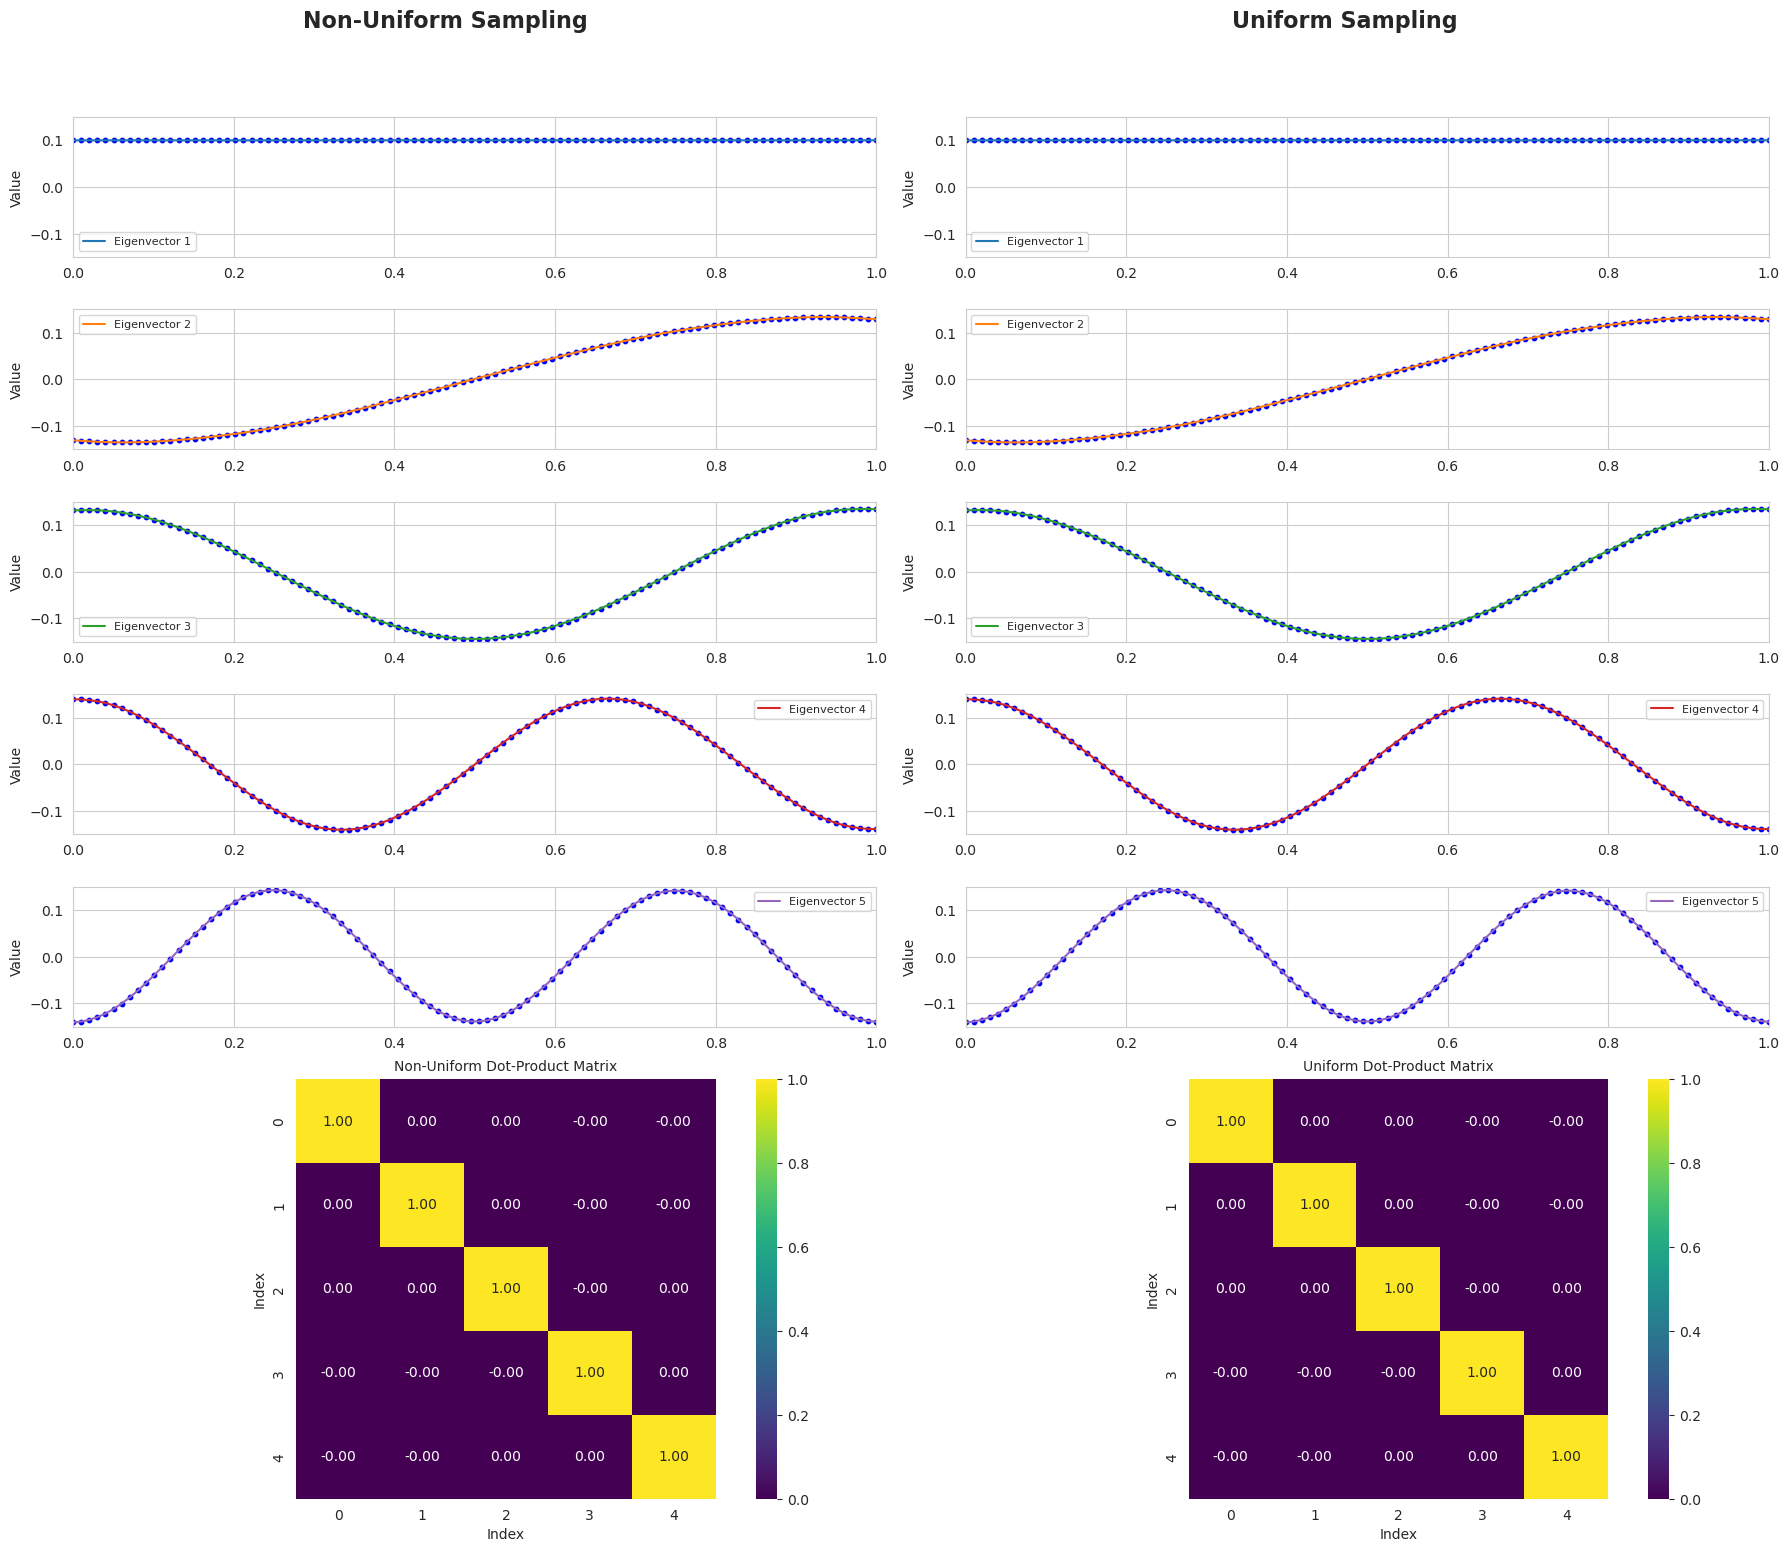

In [50]:
manifold_x = np.linspace(0, 1, 100*20)
non_uniform_x = np.random.choice(manifold_x, 100, replace=False)
non_uniform_x.sort()

non_uniform_x = torch.tensor(non_uniform_x, dtype=torch.float32)

model.eval()

f = model(non_uniform_x)

f = f.detach().cpu().numpy().reshape(5, 100)

uniform_x = np.linspace(0, 1, 100)

save_combined_plots(uniform_x, f, uniform_x, f)